In [34]:
# imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [24]:
# column names and load
SENSOR_COLS = [f"s{i}" for i in range(1, 22)]
OP_COLS = ["op1", "op2", "op3"]
ALL_COLS = ["unit", "cycle"] + OP_COLS + SENSOR_COLS

DATA_DIR = Path("/Users/murad/nasa_proj/data/raw")

train = pd.read_csv(DATA_DIR / "train_FD001.txt", sep=r"\s+", header=None, names=ALL_COLS)
test = pd.read_csv(DATA_DIR / "test_FD001.txt", sep=r"\s+", header=None, names=ALL_COLS)
rul_test = pd.read_csv(DATA_DIR / "RUL_FD001.txt", sep=r"\s+", header=None, names=["true_RUL"])
rul_test["unit"] = rul_test.index + 1

print("train shape:", train.shape)
print("test shape:", test.shape)
print("RUL shape:", rul_test.shape)
train.head()

train shape: (20631, 26)
test shape: (13096, 26)
RUL shape: (100, 2)


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


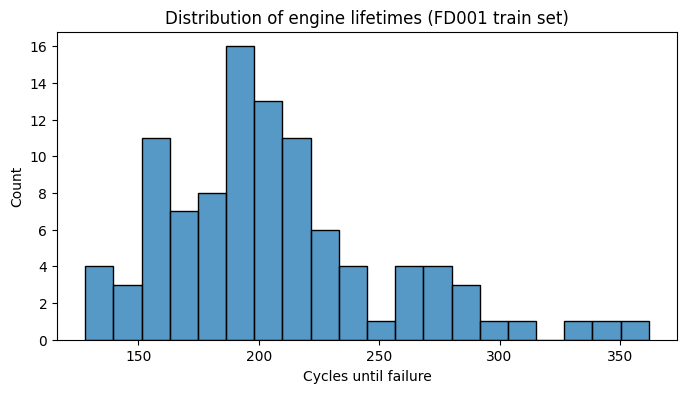

In [25]:
# how long does each engine live?
lifetimes = train.groupby("unit")["cycle"].max()
print(lifetimes.describe())

plt.figure(figsize=(8, 4))
sns.histplot(lifetimes, bins=20)
plt.xlabel("Cycles until failure")
plt.title("Distribution of engine lifetimes (FD001 train set)")
plt.show()

# Plot one engine's sensor trajectories

What to look for: sensors fall into three groups visually:

Flat lines : zero variance, no information.
Trending up or down : degradation signals. These are gold.
Noisy but stable: not useful on their own.

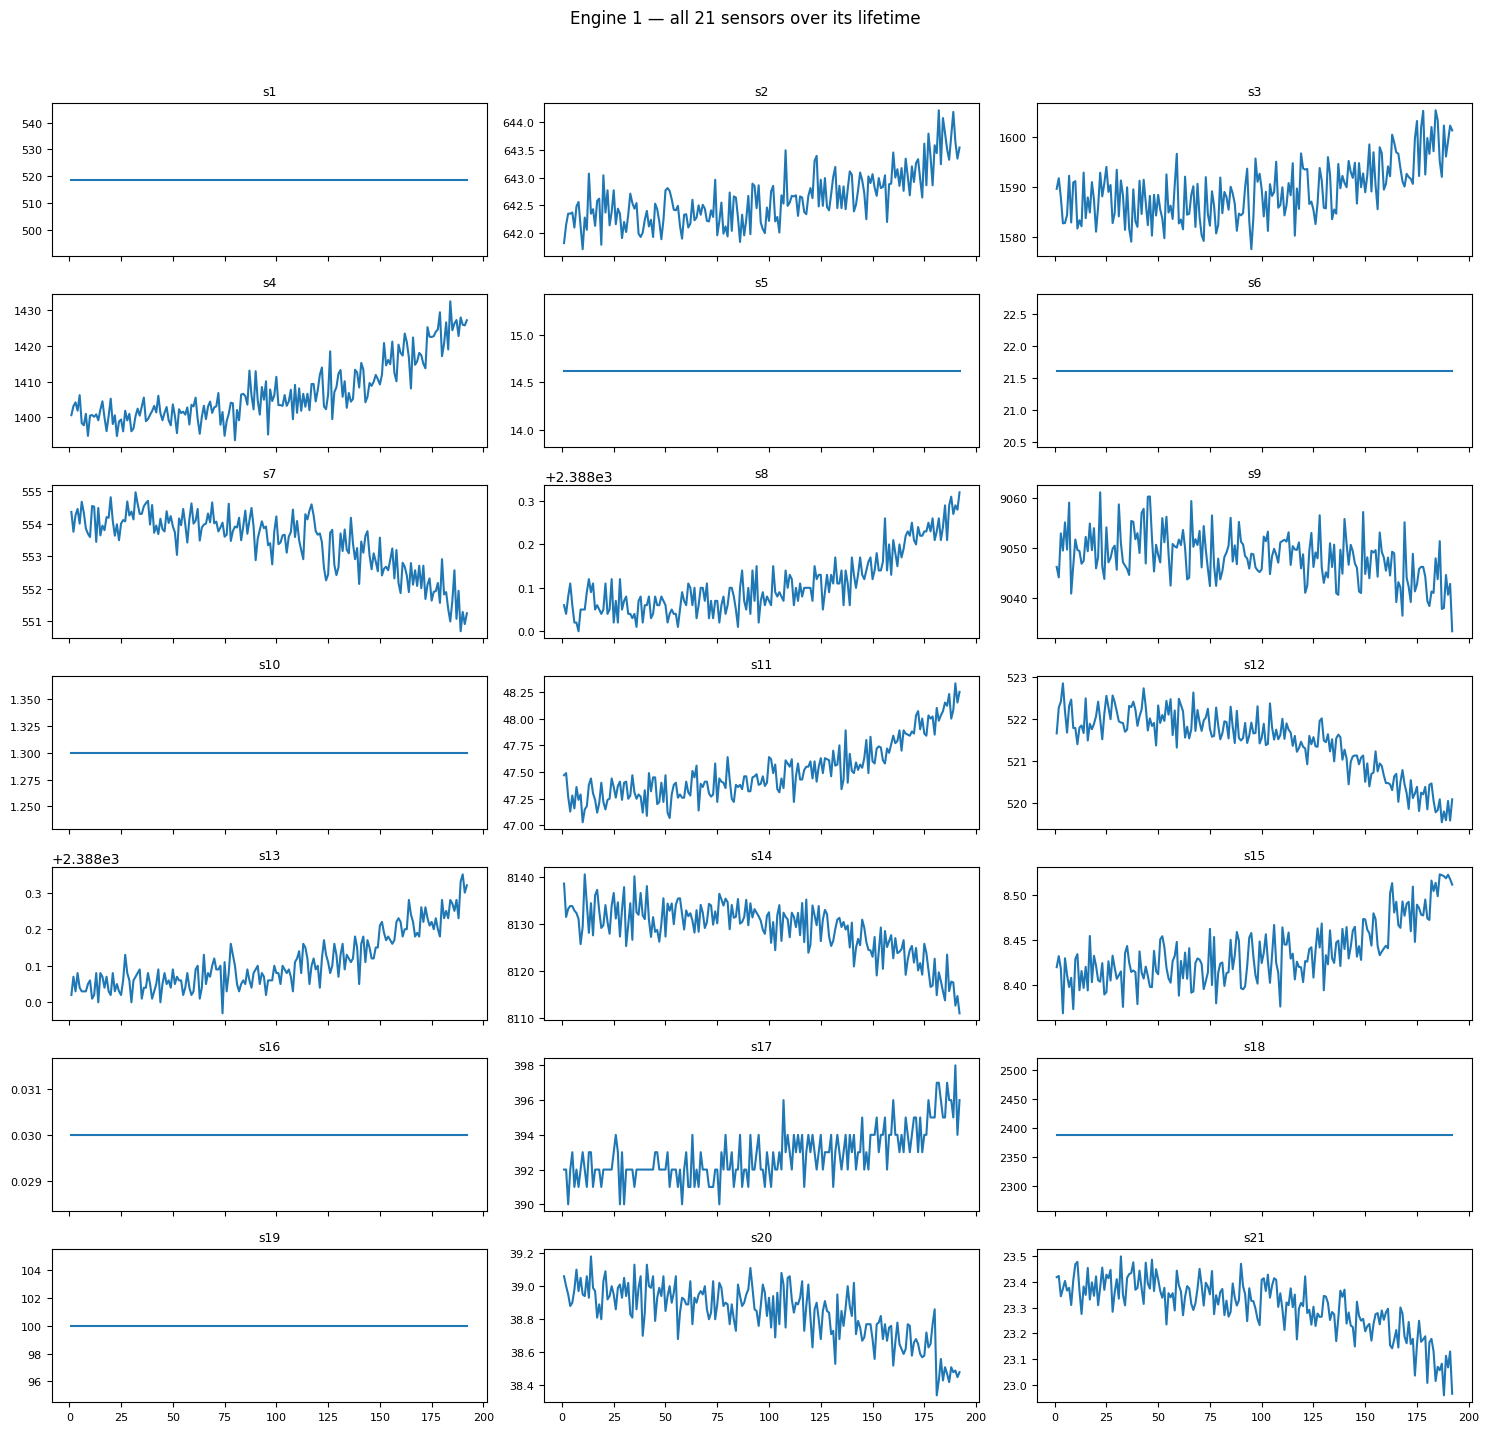

In [26]:
# visualise one engine
ENGINE_ID = 1
engine = train[train["unit"] == ENGINE_ID].copy()

fig, axes = plt.subplots(7, 3, figsize=(15, 14), sharex=True)
for i, ax in enumerate(axes.flat):
    sensor = f"s{i+1}"
    ax.plot(engine["cycle"], engine[sensor])
    ax.set_title(sensor, fontsize=9)
    ax.tick_params(labelsize=8)
fig.suptitle(f"Engine {ENGINE_ID} — all 21 sensors over its lifetime", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
# find constant sensors automatically
sensor_std = train[SENSOR_COLS].std()
constant_sensors = sensor_std[sensor_std < 1e-6].index.tolist()
informative_sensors = [s for s in SENSOR_COLS if s not in constant_sensors]

print("Constant sensors (drop these):", constant_sensors)
print(f"Informative sensors ({len(informative_sensors)}):", informative_sensors)

Constant sensors (drop these): ['s1', 's5', 's10', 's16', 's18', 's19']
Informative sensors (15): ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


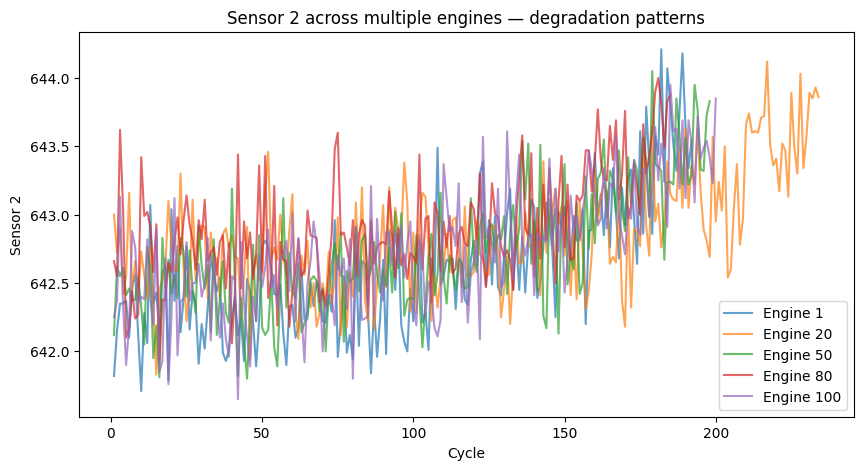

In [28]:
# overlay multiple engines on the same sensor
plt.figure(figsize=(10, 5))
for unit_id in [1, 20, 50, 80, 100]:
    e = train[train["unit"] == unit_id]
    plt.plot(e["cycle"], e["s2"], label=f"Engine {unit_id}", alpha=0.7)
plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 across multiple engines — degradation patterns")
plt.legend()
plt.show()

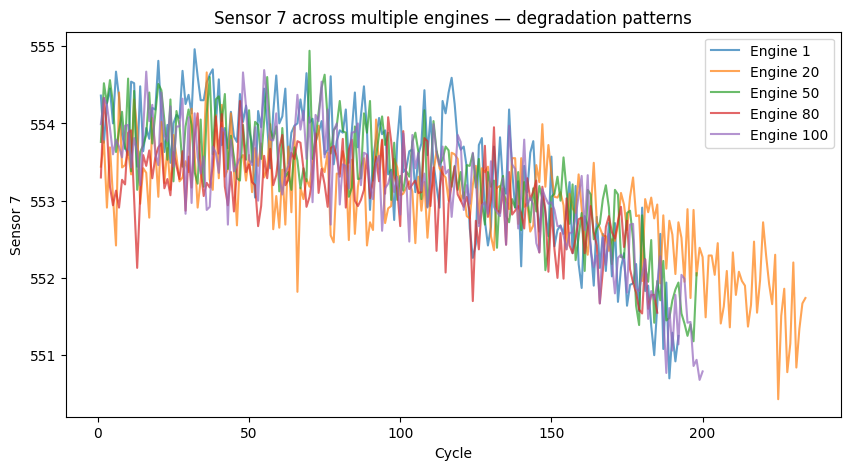

In [29]:
# overlay multiple engines on the same sensor
plt.figure(figsize=(10, 5))
for unit_id in [1, 20, 50, 80, 100]:
    e = train[train["unit"] == unit_id]
    plt.plot(e["cycle"], e["s7"], label=f"Engine {unit_id}", alpha=0.7)
plt.xlabel("Cycle")
plt.ylabel("Sensor 7")
plt.title("Sensor 7 across multiple engines — degradation patterns")
plt.legend()
plt.show()

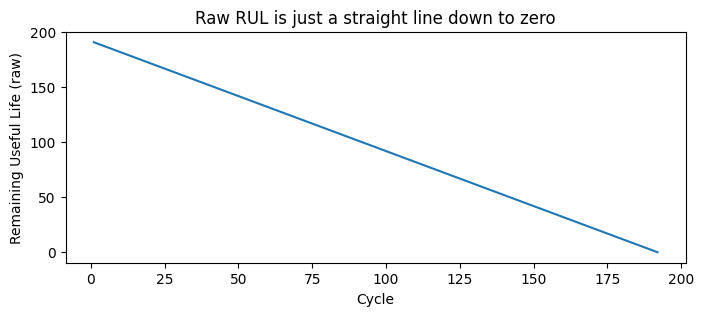

In [30]:
# raw RUL
max_cycles = train.groupby("unit")["cycle"].transform("max")
train["raw_RUL"] = max_cycles - train["cycle"]

# Visualise for one engine
e = train[train["unit"] == 1]
plt.figure(figsize=(8, 3))
plt.plot(e["cycle"], e["raw_RUL"])
plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life (raw)")
plt.title("Raw RUL is just a straight line down to zero")
plt.show()

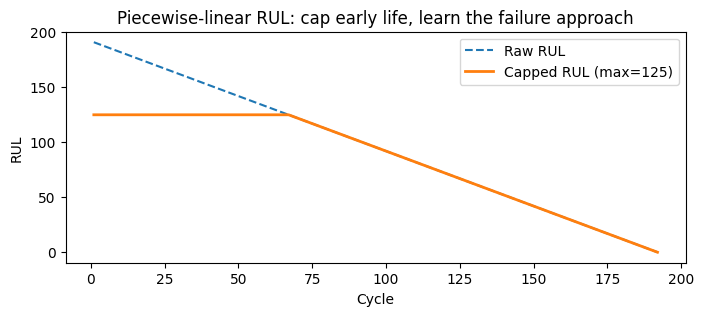

In [31]:
# piecewise-linear RUL
MAX_RUL = 125
train["RUL"] = train["raw_RUL"].clip(upper=MAX_RUL)

# Compare side by side
e = train[train["unit"] == 1]
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(e["cycle"], e["raw_RUL"], label="Raw RUL", linestyle="--")
ax.plot(e["cycle"], e["RUL"], label=f"Capped RUL (max={MAX_RUL})", linewidth=2)
ax.set_xlabel("Cycle")
ax.set_ylabel("RUL")
ax.set_title("Piecewise-linear RUL: cap early life, learn the failure approach")
ax.legend()
plt.show()

In [37]:
# import the feature function and run it
from src.features import compute_rolling_features

train_feats = compute_rolling_features(train, informative_sensors, window=30)
train_feats["RUL"] = train["RUL"].values

print("Feature shape:", train_feats.shape)
train_feats.head()

Feature shape: (20631, 63)


,unit,cycle,s2_mean,s2_std,s2_slope,s2_last,s3_mean,s3_std,s3_slope,s3_last,...,s17_last,s20_mean,s20_std,s20_slope,s20_last,s21_mean,s21_std,s21_slope,s21_last,RUL
0,1,1,641.820000,0.000000,0.000,641.82,1589.700000,0.000000,0.000,1589.70,...,392,39.060000,0.000000,0.000,39.06,23.419000,0.000000,0.00000,23.4190,125
1,1,2,641.985000,0.233345,0.330,642.15,1590.760000,1.499066,2.120,1591.82,...,392,39.030000,0.042426,-0.060,39.00,23.421300,0.003253,0.00460,23.4236,125
2,1,3,642.106667,0.267644,0.265,642.35,1589.836667,1.918654,-0.855,1587.99,...,390,39.003333,0.055076,-0.055,38.95,23.395600,0.044573,-0.03740,23.3442,125
3,1,4,642.167500,0.250117,0.179,642.35,1588.075000,3.855909,-2.456,1582.79,...,392,38.972500,0.076322,-0.059,38.88,23.390175,0.037977,-0.02147,23.3739,125
4,1,5,642.208000,0.234776,0.130,642.37,1587.030000,4.075678,-2.273,1582.85,...,393,38.958000,0.073621,-0.044,38.90,23.393020,0.033498,-0.00789,23.4044,125


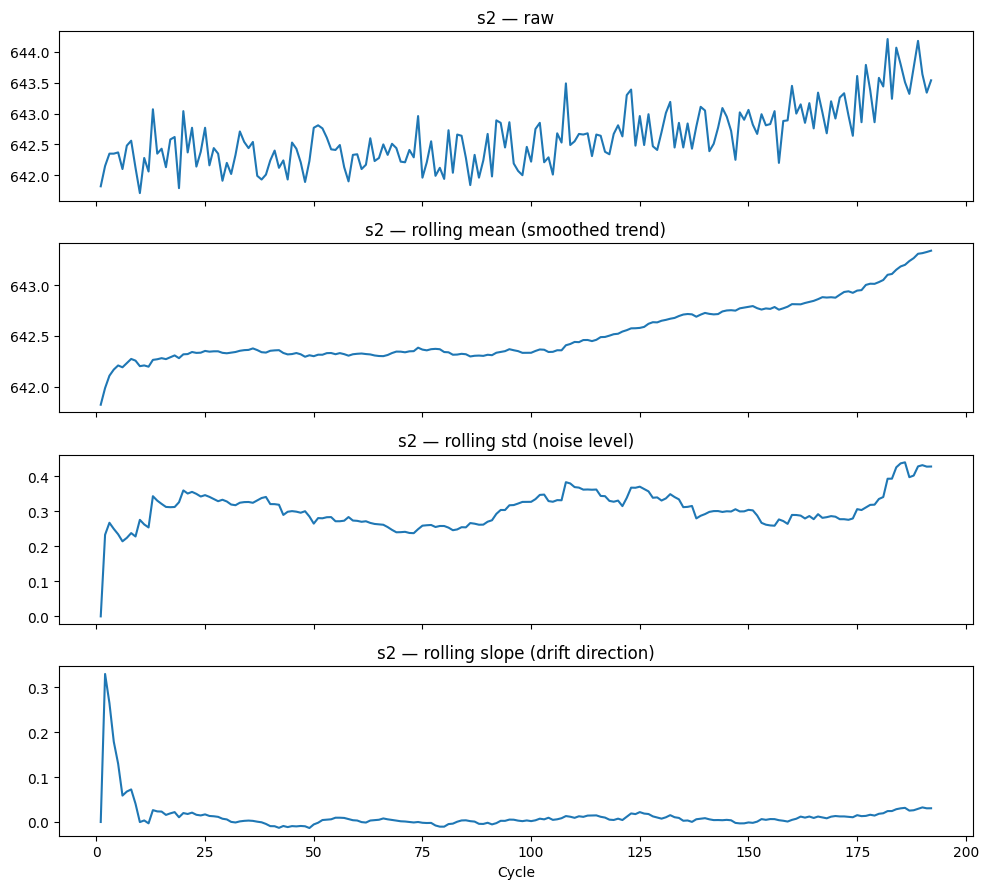

In [38]:
# feature sanity check for engine 1
e_feats = train_feats[train_feats["unit"] == 1]
sensor = "s2"

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
axes[0].plot(e_feats["cycle"], e_feats[f"{sensor}_last"]);  axes[0].set_title(f"{sensor} — raw")
axes[1].plot(e_feats["cycle"], e_feats[f"{sensor}_mean"]);  axes[1].set_title(f"{sensor} — rolling mean (smoothed trend)")
axes[2].plot(e_feats["cycle"], e_feats[f"{sensor}_std"]);   axes[2].set_title(f"{sensor} — rolling std (noise level)")
axes[3].plot(e_feats["cycle"], e_feats[f"{sensor}_slope"]); axes[3].set_title(f"{sensor} — rolling slope (drift direction)")
axes[3].set_xlabel("Cycle")
plt.tight_layout()
plt.show()

Top 15 features by absolute correlation with RUL:
s3_mean     0.785069
s17_mean    0.784733
s11_last    0.775230
s15_mean    0.774369
s4_mean     0.772380
s21_mean    0.771842
s20_mean    0.770161
s2_mean     0.765904
s11_mean    0.762135
s4_last     0.757157
s12_last    0.748870
s7_mean     0.744123
s12_mean    0.741106
s7_last     0.733021
s15_last    0.720858
Name: RUL, dtype: float64


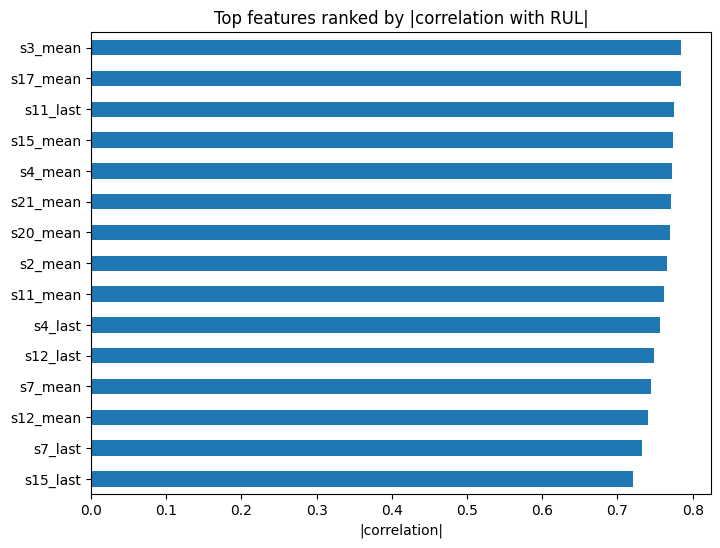

In [39]:
# which features are most correlated with RUL?
feature_cols = [c for c in train_feats.columns if c not in ("unit", "cycle", "RUL")]

corr = train_feats[feature_cols + ["RUL"]].corr()["RUL"].drop("RUL")
top = corr.abs().sort_values(ascending=False).head(15)
print("Top 15 features by absolute correlation with RUL:")
print(top)

plt.figure(figsize=(8, 6))
top.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top features ranked by |correlation with RUL|")
plt.xlabel("|correlation|")
plt.show()

In [42]:
# refit scaler on training engines only
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_va_scaled = scaler.transform(X_va)

print("X_tr_scaled mean ~ 0:", X_tr_scaled.mean(axis=0)[:3].round(3))
print("X_tr_scaled std  ~ 1:", X_tr_scaled.std(axis=0)[:3].round(3))

X_tr_scaled mean ~ 0: [-0.  0. -0.]
X_tr_scaled std  ~ 1: [1. 1. 1.]


In [43]:
# engine-level split
from sklearn.model_selection import train_test_split

unit_ids = train_feats["unit"].unique()
train_units, val_units = train_test_split(unit_ids, test_size=0.2, random_state=42)

train_idx = train_feats["unit"].isin(train_units)
val_idx   = train_feats["unit"].isin(val_units)

X_tr, y_tr = train_feats.loc[train_idx, feature_cols].values, train_feats.loc[train_idx, "RUL"].values
X_va, y_va = train_feats.loc[val_idx,   feature_cols].values, train_feats.loc[val_idx,   "RUL"].values

print(f"{len(train_units)} train engines, {len(val_units)} validation engines")
print(f"X_tr {X_tr.shape}, X_va {X_va.shape}")

80 train engines, 20 validation engines
X_tr (16561, 60), X_va (4070, 60)


# Train a Ridge regression baseline

In [44]:
# Ridge baseline
import numpy as np
from sklearn.linear_model import Ridge
from src.evaluate import report

MAX_RUL = 125  # same cap used during labelling

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_tr_scaled, y_tr)

y_va_pred_ridge = np.clip(ridge.predict(X_va_scaled), 0, MAX_RUL)
report(y_va, y_va_pred_ridge, label="Ridge (val)")

         Ridge (val)   RMSE =  17.73   NASA score =  21113.59


{'label': 'Ridge (val)',
 'rmse': 17.729443022377854,
 'nasa_score': 21113.591222204675}

# Train an XGBoost baseline

In [45]:
# XGBoost baseline
import xgboost as xgb

# Trees don't need standardised inputs, so use the raw features
xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    verbose=False,
)

y_va_pred_xgb = np.clip(xgb_model.predict(X_va), 0, MAX_RUL)
report(y_va, y_va_pred_xgb, label="XGBoost (val)")

       XGBoost (val)   RMSE =  11.70   NASA score =  10297.23


{'label': 'XGBoost (val)',
 'rmse': 11.70178420581066,
 'nasa_score': 10297.23393693312}

In [46]:
# build test set features
from src.features import compute_rolling_features, get_last_cycle_per_engine

test_feats_full = compute_rolling_features(test, informative_sensors, window=30)
test_feats = get_last_cycle_per_engine(test_feats_full)
test_feats = test_feats.merge(rul_test, on="unit")  # adds 'true_RUL'

X_test = test_feats[feature_cols].values
y_test = test_feats["true_RUL"].values
X_test_scaled = scaler.transform(X_test)  # use the scaler fit on TRAIN only

print(f"Test set: {X_test.shape[0]} engines, one prediction per engine")

Test set: 100 engines, one prediction per engine


In [47]:
# Cell: evaluate both models on the held-out test set
y_test_pred_ridge = np.clip(ridge.predict(X_test_scaled), 0, MAX_RUL)
y_test_pred_xgb   = np.clip(xgb_model.predict(X_test),   0, MAX_RUL)

print("\n--- Final test set results ---")
report(y_test, y_test_pred_ridge, label="Ridge (test)")
report(y_test, y_test_pred_xgb,   label="XGBoost (test)")


--- Final test set results ---
        Ridge (test)   RMSE =  18.44   NASA score =    650.14
      XGBoost (test)   RMSE =  15.02   NASA score =    336.19


{'label': 'XGBoost (test)',
 'rmse': 15.017434155400565,
 'nasa_score': 336.1911600269921}

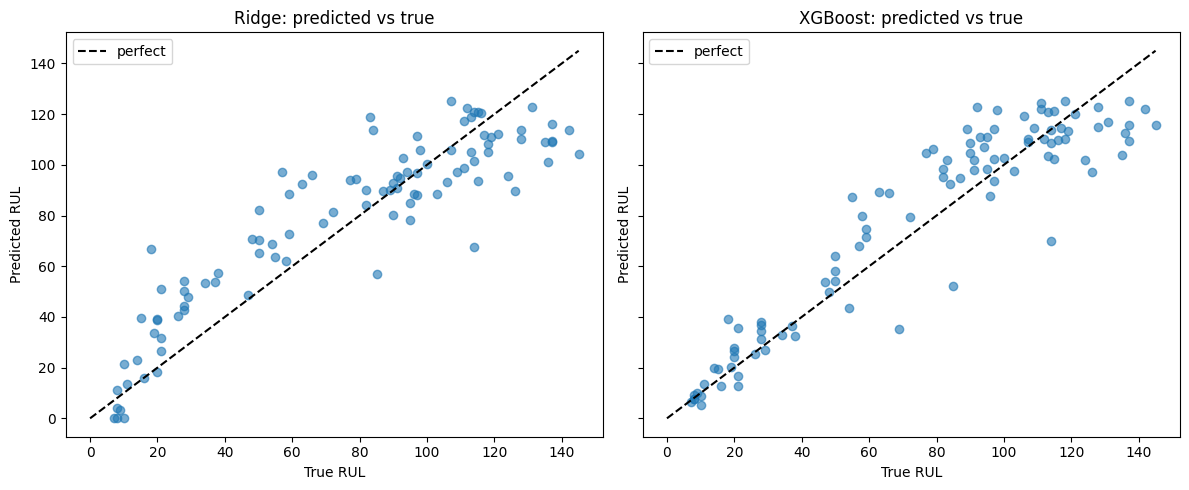

In [48]:
# scatter plot of predicted vs true RUL
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, y_pred, name in [
    (axes[0], y_test_pred_ridge, "Ridge"),
    (axes[1], y_test_pred_xgb,   "XGBoost"),
]:
    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot([0, max(y_test)], [0, max(y_test)], "k--", label="perfect")
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted RUL")
    ax.set_title(f"{name}: predicted vs true")
    ax.legend()

plt.tight_layout()
plt.show()

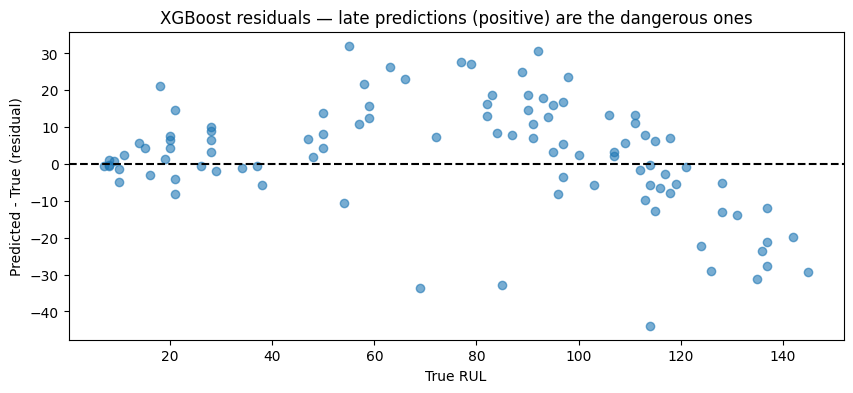

In [49]:
# residual plot — error vs true RUL
residuals_xgb = y_test_pred_xgb - y_test

plt.figure(figsize=(10, 4))
plt.scatter(y_test, residuals_xgb, alpha=0.6)
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("True RUL")
plt.ylabel("Predicted - True (residual)")
plt.title("XGBoost residuals — late predictions (positive) are the dangerous ones")
plt.show()

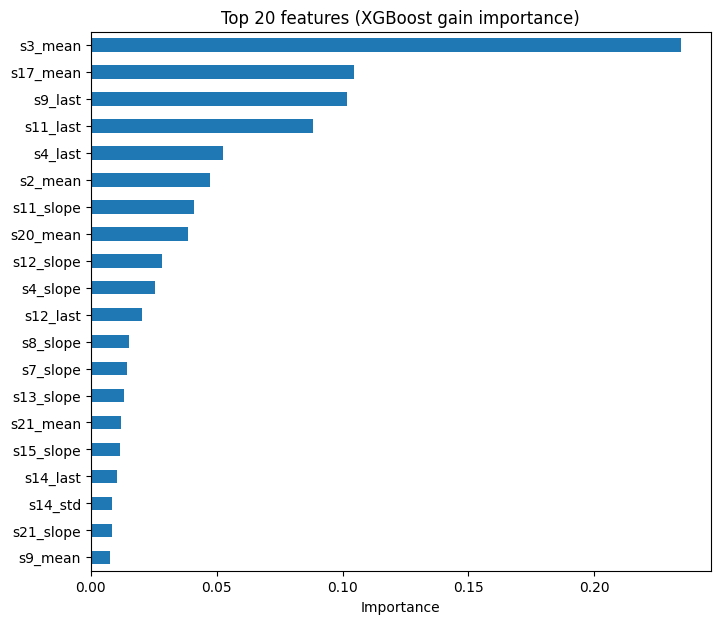


Top 5 feature types:
s3_mean     0.234631
s17_mean    0.104490
s9_last     0.101776
s11_last    0.088400
s4_last     0.052489


In [50]:
# Cell: which features mattered most to XGBoost?
import pandas as pd

importance = pd.Series(xgb_model.feature_importances_, index=feature_cols)
top20 = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 7))
top20.iloc[::-1].plot(kind="barh")
plt.title("Top 20 features (XGBoost gain importance)")
plt.xlabel("Importance")
plt.show()

print("\nTop 5 feature types:")
print(top20.head().to_string())

In [51]:
# Cell: persist predictions
from pathlib import Path

out = Path("../data/processed")
out.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "unit": test_feats["unit"].values,
    "true_RUL": y_test,
    "ridge_RUL": y_test_pred_ridge,
    "xgb_RUL":   y_test_pred_xgb,
}).to_parquet(out / "baseline_predictions_FD001.parquet")

print("Saved →", out / "baseline_predictions_FD001.parquet")

Saved → ../data/processed/baseline_predictions_FD001.parquet


In [52]:
!uv run python src/train_base.py

/Users/murad/nasa_proj/.venv/bin/python3: can't open file '/Users/murad/nasa_proj/notebooks/src/train_base.py': [Errno 2] No such file or directory
